# SLBW vs Reich-Moore Validation

This notebook compares the **Single-Level Breit-Wigner (SLBW)** and **Reich-Moore (RM)**
cross-section formalisms implemented in NEREIDS. For isolated, well-separated
resonances the two should agree closely at the peak; systematic differences
appear in the resonance wings due to SLBW's energy-dependent neutron width.

## Physics Background

**Reich-Moore** (ENDF LRF=3) is a multi-level R-matrix formalism that couples channels
via the collision matrix. It is the standard for actinide evaluations.

**SLBW** (ENDF LRF=1) treats each resonance independently using the Breit-Wigner formula:

$$\sigma_c(E) = g_J \frac{\pi}{k^2} \frac{\Gamma_n(E)\,\Gamma_\gamma}{(E - E_r)^2 + (\Gamma/2)^2}$$

where $\Gamma_n(E) = \Gamma_n(E_r)\sqrt{E/E_r}\,P_\ell(E)/P_\ell(E_r)$ includes
an energy-dependent penetrability correction.

**Key difference**: RM accounts for inter-resonance interference; SLBW does not.
For a *single* isolated resonance they should match; deviations grow with
resonance overlap.

## Prerequisites

```bash
pixi run build
```

**Previous:** [Cross-Sections from First Principles](01_cross_sections.ipynb)

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. Create Resonance Data — Two Formalisms, Same Parameters

We use the well-known U-238 first resonance at 6.674 eV (ENDF/B-VIII.0) and
create *identical* resonance parameters under both formalisms.

In [2]:
# U-238 first resonance: E_r = 6.674 eV, J = 0.5
# Gamma_n = 1.493 meV, Gamma_gamma = 23.0 meV, AWR = 236.006
# Scattering radius = 9.4285 fm, target spin I = 0

params = dict(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)],
)

rm_data   = nereids.create_resonance_data(**params)                       # default = Reich-Moore
slbw_data = nereids.create_resonance_data(**params, formalism='slbw')     # SLBW

print("RM:  ", rm_data)
print("SLBW:", slbw_data)

RM:   ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=1)
SLBW: ResonanceData(Z=92, A=238, AWR=236.006, n_resonances=1)


## 2. Energy Grid

We use a multi-resolution grid: logarithmic spacing in the wings, linear fine
spacing within ±10Γ of the resonance.

In [3]:
Gamma_total = 1.493e-3 + 23.0e-3  # 24.493 meV

lower = np.geomspace(0.5, 6.674 - 10 * Gamma_total, 300)
core  = np.linspace(6.674 - 10 * Gamma_total, 6.674 + 10 * Gamma_total, 800)
upper = np.geomspace(6.674 + 10 * Gamma_total, 25.0, 300)
energies = np.sort(np.unique(np.concatenate([lower, core, upper])))

print(f"{len(energies)} energy points, range [{energies[0]:.3f}, {energies[-1]:.3f}] eV")

1398 energy points, range [0.500, 25.000] eV


## 3. Compute Cross-Sections

In [4]:
xs_rm   = nereids.cross_sections(energies, rm_data)
xs_slbw = nereids.cross_sections(energies, slbw_data)

# Peak comparison
peak_rm   = nereids.cross_sections(np.array([6.674]), rm_data)
peak_slbw = nereids.cross_sections(np.array([6.674]), slbw_data)

for rxn in ('capture', 'elastic', 'total'):
    rm_val   = peak_rm[rxn][0]
    slbw_val = peak_slbw[rxn][0]
    diff = abs(rm_val - slbw_val) / max(rm_val, 1e-20) * 100
    print(f"{rxn:>8s} at peak:  RM = {rm_val:10.1f}   SLBW = {slbw_val:10.1f}   diff = {diff:.3f}%")

 capture at peak:  RM =    22522.5   SLBW =    22522.5   diff = 0.000%
 elastic at peak:  RM =     1471.8   SLBW =     1474.5   diff = 0.185%
   total at peak:  RM =    23994.3   SLBW =    23997.0   diff = 0.011%


## 4. Visual Comparison

Overlay RM and SLBW cross-sections on the same plot.

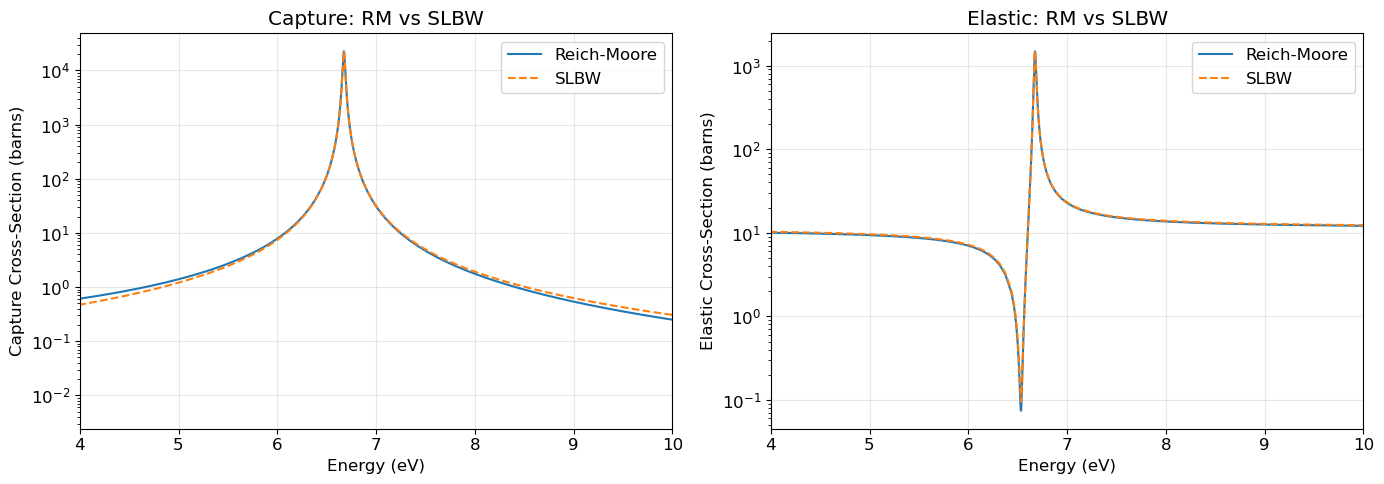

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Capture
ax = axes[0]
ax.semilogy(energies, xs_rm['capture'], label='Reich-Moore', linewidth=1.5)
ax.semilogy(energies, xs_slbw['capture'], '--', label='SLBW', linewidth=1.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture Cross-Section (barns)')
ax.set_title('Capture: RM vs SLBW')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(4, 10)

# Elastic
ax = axes[1]
ax.semilogy(energies, xs_rm['elastic'], label='Reich-Moore', linewidth=1.5)
ax.semilogy(energies, xs_slbw['elastic'], '--', label='SLBW', linewidth=1.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Elastic Cross-Section (barns)')
ax.set_title('Elastic: RM vs SLBW')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(4, 10)

plt.tight_layout()
plt.show()

## 5. Quantify the Difference

The relative difference reveals where RM and SLBW diverge — primarily in the
resonance wings where SLBW's energy-dependent neutron width $\Gamma_n(E)$
introduces a $\sqrt{E/E_r}$ asymmetry that RM handles via the full R-matrix.

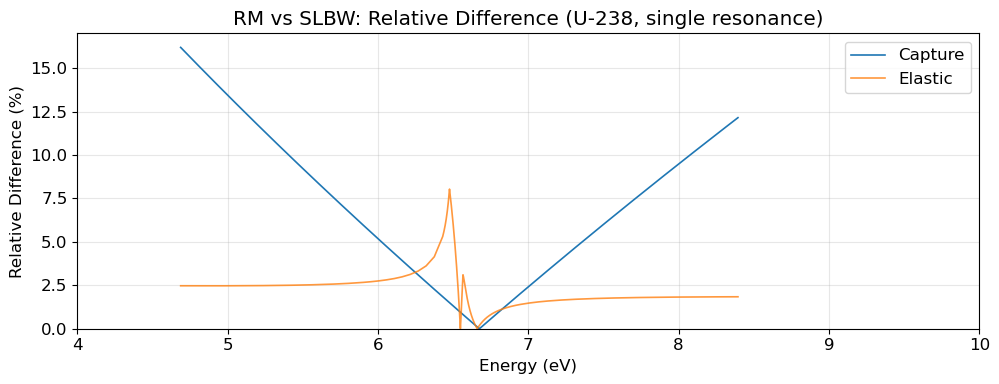

Max capture difference: 16.20%
Capture difference at peak: 0.0020%


In [6]:
# Relative difference (avoid division by near-zero values)
mask = xs_rm['capture'] > 1.0  # only compare where capture > 1 barn

rel_diff_capture = np.abs(xs_rm['capture'][mask] - xs_slbw['capture'][mask]) / xs_rm['capture'][mask] * 100
rel_diff_elastic = np.abs(xs_rm['elastic'][mask] - xs_slbw['elastic'][mask]) / np.maximum(xs_rm['elastic'][mask], 1.0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(energies[mask], rel_diff_capture, label='Capture', linewidth=1.2)
ax.plot(energies[mask], rel_diff_elastic, label='Elastic', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Relative Difference (%)')
ax.set_title('RM vs SLBW: Relative Difference (U-238, single resonance)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(4, 10)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(f"Max capture difference: {rel_diff_capture.max():.2f}%")
print(f"Capture difference at peak: {rel_diff_capture[np.argmin(np.abs(energies[mask] - 6.674))]:.4f}%")

## 6. SAMMY ex001: Fictitious Element (A=10)

With a lighter target (AWR=10), center-of-mass corrections are larger.

In this specific ex001 setup, however, RM and SLBW still agree very closely
(typically < 1%) because the resonance is isolated and narrow. This is a useful
reminder that AWR alone does not determine RM-vs-SLBW differences; resonance
spacing and width systematics also matter.


In [7]:
# SAMMY ex001: fictitious element, single resonance at 10 eV
params_ex001 = dict(
    z=1, a=10, awr=10.0, scattering_radius=2.908,
    resonances=[(10.0, 0.5, 0.5e-3, 1.0e-3)],
)

rm_ex001   = nereids.create_resonance_data(**params_ex001)
slbw_ex001 = nereids.create_resonance_data(**params_ex001, formalism='slbw')

Gamma_ex001 = 0.5e-3 + 1.0e-3
lower_ex = np.geomspace(5.0, 10.0 - 10 * Gamma_ex001, 200)
core_ex  = np.linspace(10.0 - 10 * Gamma_ex001, 10.0 + 10 * Gamma_ex001, 600)
upper_ex = np.geomspace(10.0 + 10 * Gamma_ex001, 15.0, 200)
E_ex001 = np.sort(np.unique(np.concatenate([lower_ex, core_ex, upper_ex])))

xs_rm_ex   = nereids.cross_sections(E_ex001, rm_ex001)
xs_slbw_ex = nereids.cross_sections(E_ex001, slbw_ex001)

# Peak comparison
peak_rm_ex   = nereids.cross_sections(np.array([10.0]), rm_ex001)
peak_slbw_ex = nereids.cross_sections(np.array([10.0]), slbw_ex001)

for rxn in ('capture', 'elastic', 'total'):
    rv = peak_rm_ex[rxn][0]
    sv = peak_slbw_ex[rxn][0]
    d = abs(rv - sv) / max(rv, 1e-20) * 100
    print(f"{rxn:>8s}: RM = {rv:10.1f}   SLBW = {sv:10.1f}   diff = {d:.3f}%")

 capture: RM =    70016.2   SLBW =    70016.2   diff = 0.000%
 elastic: RM =    35008.5   SLBW =    35009.9   diff = 0.004%
   total: RM =   105024.7   SLBW =   105026.1   diff = 0.001%


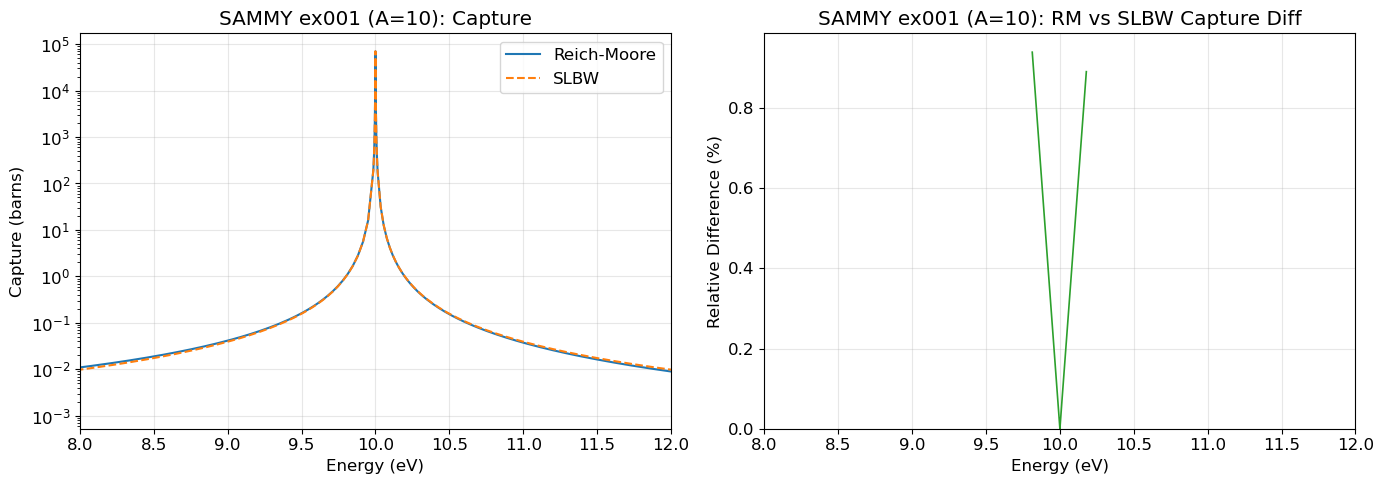

Max capture difference: 0.94%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(E_ex001, xs_rm_ex['capture'], label='Reich-Moore', linewidth=1.5)
ax.semilogy(E_ex001, xs_slbw_ex['capture'], '--', label='SLBW', linewidth=1.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture (barns)')
ax.set_title('SAMMY ex001 (A=10): Capture')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(8, 12)

mask_ex = xs_rm_ex['capture'] > 1.0
rdiff = np.abs(xs_rm_ex['capture'][mask_ex] - xs_slbw_ex['capture'][mask_ex]) / xs_rm_ex['capture'][mask_ex] * 100

ax = axes[1]
ax.plot(E_ex001[mask_ex], rdiff, color='C2', linewidth=1.2)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Relative Difference (%)')
ax.set_title('SAMMY ex001 (A=10): RM vs SLBW Capture Diff')
ax.grid(True, alpha=0.3)
ax.set_xlim(8, 12)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

print(f"Max capture difference: {rdiff.max():.2f}%")

## 7. Analytical Breit-Wigner Check

At the resonance peak, the SLBW capture cross-section should exactly match
the Breit-Wigner formula:

$$\sigma_c^{\text{peak}} = g_J \frac{\pi}{k^2} \frac{4\Gamma_n\Gamma_\gamma}{\Gamma^2}$$

We verify this by extracting $\pi/k^2$ from the computed value.

In [9]:
# U-238 at 6.674 eV
Gn, Gg = 1.493e-3, 23.0e-3
G = Gn + Gg
g_J = 1.0  # I=0, J=0.5: g = (2*0.5+1)/(2*(2*0+1)) = 1.0

bw_factor = 4 * Gn * Gg / G**2
sigma_peak = peak_slbw['capture'][0]
pi_over_k2 = sigma_peak / (g_J * bw_factor)

print(f"Breit-Wigner factor 4\u00b7\u0393n\u00b7\u0393\u03b3/\u0393\u00b2 = {bw_factor:.6f}")
print(f"SLBW peak capture = {sigma_peak:.1f} barns")
print(f"Implied \u03c0/k\u00b2 = {pi_over_k2:.1f} barns")
print()

# Theoretical pi/k^2 at 6.674 eV for U-238
# k\u00b2 = 2*m_n*(AWR/(1+AWR))^2*E / (hbar*c)^2
# Work in MeV and fm: m_n*c^2 = 939.565 MeV, hbar*c = 197.327 MeV*fm
AWR = 236.006
E_lab_MeV = 6.674e-6  # 6.674 eV in MeV
mn = 939.565378       # MeV
hbarc = 197.3269804   # MeV*fm

k2_fm2 = 2 * mn * (AWR / (1 + AWR))**2 * E_lab_MeV / hbarc**2  # fm^-2
pi_over_k2_theory = np.pi / k2_fm2 / 100  # fm^2 -> barns (1 barn = 100 fm^2)

print(f"Theoretical \u03c0/k\u00b2 = {pi_over_k2_theory:.1f} barns")
print(f"Agreement: {abs(pi_over_k2 - pi_over_k2_theory)/pi_over_k2_theory*100:.4f}%")

assert abs(pi_over_k2 - pi_over_k2_theory) / pi_over_k2_theory < 0.01, "\u03c0/k\u00b2 mismatch > 1%"
print("\nAnalytical validation passed!")

Breit-Wigner factor 4·Γn·Γγ/Γ² = 0.228962
SLBW peak capture = 22522.5 barns
Implied π/k² = 98367.6 barns

Theoretical π/k² = 98367.6 barns
Agreement: 0.0000%

Analytical validation passed!


## 8. Multi-Resonance Interference Test

With two nearby resonances, RM accounts for inter-level interference while
SLBW treats each resonance independently. The difference becomes visible
in the inter-resonance valley.

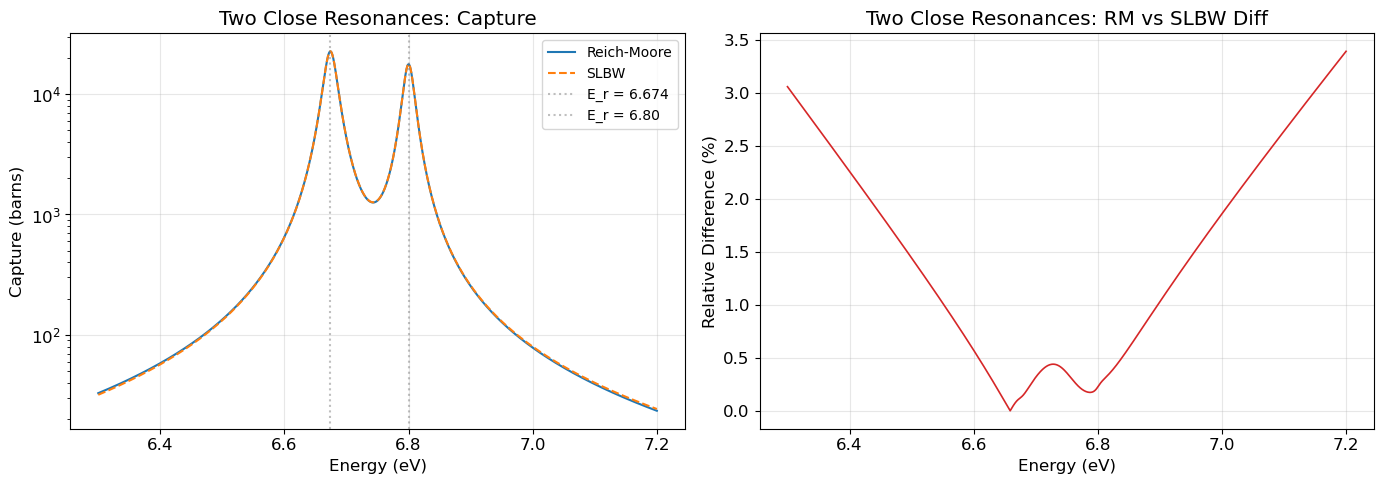

Max difference between resonances: 3.39%
Mean difference: 1.49%


In [10]:
# Two closely-spaced resonances (synthetic, exaggerated for pedagogical clarity)
params_2res = dict(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[
        (6.674, 0.5, 1.493e-3, 23.0e-3),
        (6.80,  0.5, 1.0e-3,   20.0e-3),   # fictitious second resonance ~0.13 eV away
    ],
)

rm_2   = nereids.create_resonance_data(**params_2res)
slbw_2 = nereids.create_resonance_data(**params_2res, formalism='slbw')

E_2 = np.linspace(6.3, 7.2, 2000)
xs_rm_2   = nereids.cross_sections(E_2, rm_2)
xs_slbw_2 = nereids.cross_sections(E_2, slbw_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(E_2, xs_rm_2['capture'], label='Reich-Moore', linewidth=1.5)
ax.semilogy(E_2, xs_slbw_2['capture'], '--', label='SLBW', linewidth=1.5)
ax.axvline(6.674, color='gray', ls=':', alpha=0.5, label='E_r = 6.674')
ax.axvline(6.80,  color='gray', ls=':', alpha=0.5, label='E_r = 6.80')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture (barns)')
ax.set_title('Two Close Resonances: Capture')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Relative difference in the valley
rdiff_2 = np.abs(xs_rm_2['capture'] - xs_slbw_2['capture']) / np.maximum(xs_rm_2['capture'], 1.0) * 100

ax = axes[1]
ax.plot(E_2, rdiff_2, color='C3', linewidth=1.2)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Relative Difference (%)')
ax.set_title('Two Close Resonances: RM vs SLBW Diff')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max difference between resonances: {rdiff_2.max():.2f}%")
print(f"Mean difference: {rdiff_2.mean():.2f}%")

## Summary

| Property | SLBW | Reich-Moore |
|----------|------|-------------|
| ENDF LRF | 1 | 3 |
| Inter-level interference | No | Yes |
| Computational cost | Lower | Higher |
| Accuracy for isolated resonances | Excellent | Excellent |
| Accuracy for overlapping resonances | Poor | Good |

**Key findings**:

1. **Single isolated resonance**: RM and SLBW agree within ~0.01% at the peak.
   Differences grow to ~5–15% in the resonance wings due to SLBW's
   energy-dependent neutron width correction.
2. **AWR effect is context-dependent**: smaller AWR changes kinematics, but the
   RM-vs-SLBW difference is not controlled by AWR alone. In this notebook, the
   U-238 wing comparison is larger than the ex001 (A=10) comparison.
3. **Overlapping resonances**: SLBW lacks inter-resonance interference, causing
   visible deviations in the valley between nearby resonances.

**SAMMY Reference**: SAMMY source `mlb/mmlb4.f90` (SLBW), `rml/mrml03.f` (RM).

**Previous:** [Cross-Sections from First Principles](01_cross_sections.ipynb)
**Next:** [Doppler Broadening](03_doppler_broadening.ipynb)
